In [1]:
# CONFIGURATION
# =============
# Add/remove LLMs here.
LLMS = [
    {'name': 'Mistral-7B-v0.1',              'pretty': 'Mistral-7B-v0.1',              'num_layers': 32},
    {'name': 'DeepSeek-R1-Distill-Llama-8B', 'pretty': 'DeepSeek-R1-Distill-Llama-8B', 'num_layers': 32},
    {'name': 'Qwen3-8B',                     'pretty': 'Qwen3-8B',                     'num_layers': 36},
    {'name': 'Llama-2-7b-hf',                'pretty': 'Llama-2-7b-hf',                'num_layers': 32},
    {'name': 'OLMo-2-1124-7B-Instruct',      'pretty': 'OLMo-2-1124-7B-Instruct',      'num_layers': 32},
    {'name': 'DeepSeek-R1-Distill-Qwen-7B',  'pretty': 'DeepSeek-R1-Distill-Qwen-7B',  'num_layers': 28},
    {'name': 'Llama-3.1-8B-Instruct',        'pretty': 'Llama-3.1-8B-Instruct',        'num_layers': 32},
]

# Specify the probing setting
PROBE_SETTING = 'dec_sci_compare'  # e.g., 'dec_dec_compare', 'int_sci_compare'

# Offsets for each probe type
OFFSET_REGRESSION = 'mixed_offset_0'       # e.g., 'mixed_offset_0', 'int_offset_0', 'sci_offset_0' for int-sci comparison
OFFSET_CLASSIFICATION = 'last_token'       # e.g., 'last_token', 'concat_offset_0'

# Where to save figures
SAVE_FIG_PATH = '../figures/'

# Which split to use
SPLIT = 'val'

# Which verbalization setting to use (should match PROBE_SETTING)
VERBALIZATION_SETTING = PROBE_SETTING


In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# Create save directory
os.makedirs(SAVE_FIG_PATH, exist_ok=True)
os.makedirs(os.path.join(SAVE_FIG_PATH, "layerwise", PROBE_SETTING), exist_ok=True)
os.makedirs(os.path.join(SAVE_FIG_PATH, "correlation", PROBE_SETTING), exist_ok=True)

def get_probe_results(base_dir, llm, probe_setting, probe_type, offset, split):
    """Load probe results for a given LLM and setting."""
    base = f'../{base_dir}/{llm}/{probe_setting}/{probe_type}'
    path = os.path.join(base, offset, f'{split}_results.json')
    preds_path = os.path.join(base, offset, 'test_preds.npy')

    if not os.path.exists(path):
        print(f'Warning: {path} not found!')
        return None

    with open(path, 'r') as f:
        data = json.load(f)

    if not os.path.exists(preds_path):
        print(f'Warning: {preds_path} not found!')
        preds = None
    else:
        preds = np.load(preds_path)

    return data, preds

def get_verbalization_acc(llm, setting):
    """Load verbalization accuracy for a given LLM and setting."""
    path = f'../verbalization-test/{llm}/{setting}.jsonl'
    if not os.path.exists(path):
        print(f'Warning: {path} not found!')
        return None

    with open(path, 'r') as f:
        first_line = f.readline()
        if not first_line.strip():
            return None
        result = json.loads(first_line)
    return result.get('overall_accuracy', None)

def get_verbalization_results(llm, setting):
    """Load verbalization results for a given LLM and setting."""
    path = f'../verbalization-test/{llm}/{setting}.jsonl'
    if not os.path.exists(path):
        print(f'Warning: {path} not found!')
        return None
    with open(path, 'r') as f:
        results = [json.loads(line) for line in f]
    return results


In [5]:
# Load all results
regression_probe_results = {}
regression_probe_preds = {}
classification_probe_results = {}
classification_probe_preds = {}
log_ratio_regression_probe_results = {}
log_ratio_regression_probe_preds = {}
verbalization_accs = {}
verbalization_results = {}

for llm in LLMS:
    name = llm['name']
    results, preds = get_probe_results("results", name, PROBE_SETTING, "regression", OFFSET_REGRESSION, SPLIT)
    regression_probe_results[name] = results
    regression_probe_preds[name] = preds

    results, preds = get_probe_results("results", name, PROBE_SETTING, "classification", OFFSET_CLASSIFICATION, SPLIT)
    classification_probe_results[name] = results
    classification_probe_preds[name] = preds

    results, preds = get_probe_results("results", name, PROBE_SETTING, "regression_diff", OFFSET_CLASSIFICATION, SPLIT)
    log_ratio_regression_probe_results[name] = results
    log_ratio_regression_probe_preds[name] = preds

    verbalization_accs[name] = get_verbalization_acc(name, VERBALIZATION_SETTING)
    verbalization_results[name] = get_verbalization_results(name, VERBALIZATION_SETTING)

print('Loaded LLMs:', list(regression_probe_results.keys()))
print('\nVerbalization Accuracies:')
for name, acc in verbalization_accs.items():
    print(f'  {name}: {acc}')


Loaded LLMs: ['Mistral-7B-v0.1', 'DeepSeek-R1-Distill-Llama-8B', 'Qwen3-8B', 'Llama-2-7b-hf', 'OLMo-2-1124-7B-Instruct', 'DeepSeek-R1-Distill-Qwen-7B', 'Llama-3.1-8B-Instruct']

Verbalization Accuracies:
  Mistral-7B-v0.1: 0.455
  DeepSeek-R1-Distill-Llama-8B: 0.581875
  Qwen3-8B: 0.7575
  Llama-2-7b-hf: 0.529375
  OLMo-2-1124-7B-Instruct: 0.59125
  DeepSeek-R1-Distill-Qwen-7B: 0.675625
  Llama-3.1-8B-Instruct: 0.55


In [6]:
ex_llm_name = 'Mistral-7B-v0.1'

ex_reg_results = regression_probe_results[ex_llm_name]
ex_cls_results = classification_probe_results[ex_llm_name]
ex_lrreg_results = log_ratio_regression_probe_results[ex_llm_name]

ex_reg_preds = regression_probe_preds[ex_llm_name]
ex_cls_preds = classification_probe_preds[ex_llm_name]
ex_lrreg_preds = log_ratio_regression_probe_preds[ex_llm_name]

In [7]:
ex_reg_preds.shape, ex_cls_preds.shape, ex_lrreg_preds.shape

((32, 3200), (32, 1600), (32, 1600))

<Axes: >

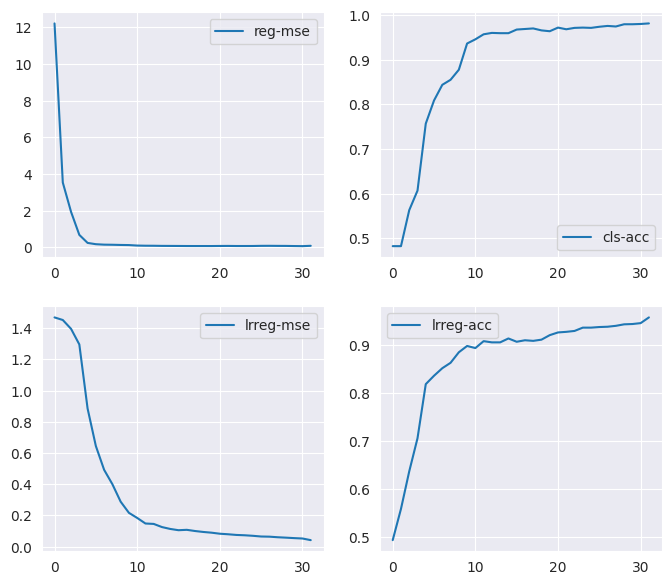

In [8]:
# sanity check
import seaborn as sns
sns.set_style('darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(8, 7))
sns.lineplot([r["val_mse"] for r in ex_reg_results], label="reg-mse", ax=axes[0, 0])
sns.lineplot([r["val_acc"] for r in ex_cls_results], label="cls-acc", ax=axes[0, 1])
sns.lineplot([r["val_mse"] for r in ex_lrreg_results], label="lrreg-mse", ax=axes[1, 0])
sns.lineplot([r["val_acc"] for r in ex_lrreg_results], label="lrreg-acc", ax=axes[1, 1])

In [9]:
ex_best_layer = min(enumerate(ex_reg_results), key=lambda x: x[1]["val_mse"])[0]
ex_best_layer

30

In [10]:
ex_verb_results = verbalization_results[ex_llm_name]
len(ex_verb_results), ex_verb_results[0], ex_verb_results[2]

(1602,
 {'total_samples': 1600,
  'correct_samples': 728,
  'overall_accuracy': 0.455,
  'digit_accuracies': {'2': {'correct': 117, 'total': 200, 'accuracy': 0.585},
   '3': {'correct': 87, 'total': 200, 'accuracy': 0.435},
   '4': {'correct': 94, 'total': 200, 'accuracy': 0.47},
   '5': {'correct': 84, 'total': 200, 'accuracy': 0.42},
   '6': {'correct': 84, 'total': 200, 'accuracy': 0.42},
   '7': {'correct': 85, 'total': 200, 'accuracy': 0.425},
   '8': {'correct': 89, 'total': 200, 'accuracy': 0.445},
   '9': {'correct': 88, 'total': 200, 'accuracy': 0.44}},
  'error_count': 0},
 {'id': 0,
  'digit': 2,
  'a': '76.6',
  'b': '3.3544 × 10^1',
  'model_output': 'Q: Which is larger, 899.9 or 9.9 × 10^2? A: 9.9 × 10^2\nQ: Which is larger, 76.6 or 3.3544 × 10^1? A: 3.3544 × 10^1',
  'comparison_correct': False})

In [11]:
import pandas as pd

In [12]:
dfs = {}
for name, results in verbalization_results.items():
    # process regression results
    reg_results = regression_probe_results[name]
    best_reg_layer = min(enumerate(reg_results), key=lambda x: x[1]["val_mse"])[0]
    reg_preds = regression_probe_preds[name][best_reg_layer].reshape(-1, 2)

    # process classification results
    cls_results = classification_probe_results[name]
    best_cls_layer = max(enumerate(cls_results), key=lambda x: x[1]["val_acc"])[0]
    cls_preds = classification_probe_preds[name][best_cls_layer]

    # process log-ratio regression results
    lrreg_results = log_ratio_regression_probe_results[name]
    best_lrreg_layer = min(enumerate(lrreg_results), key=lambda x: x[1]["val_mse"])[0]
    lrreg_preds = log_ratio_regression_probe_preds[name][best_lrreg_layer]

    df = pd.DataFrame(results[2:])
    df["model"] = name
    # regression cols
    df["best_reg_layer"] = best_reg_layer
    df["best_reg_mse"] = reg_results[best_reg_layer]["val_mse"]
    df["reg_pred_a"] = reg_preds[:, 0]
    df["reg_pred_b"] = reg_preds[:, 1]
    # classification cols
    df["best_cls_layer"] = best_cls_layer
    df["best_cls_acc"] = cls_results[best_cls_layer]["val_acc"]
    df["cls_pred"] = cls_preds
    # log-ratio regression cols
    df["best_lrreg_layer"] = best_lrreg_layer
    df["best_lrreg_mse"] = lrreg_results[best_lrreg_layer]["val_mse"]
    df["best_lrreg_acc"] = lrreg_results[best_lrreg_layer]["val_acc"]
    df["lrreg_pred"] = lrreg_preds
    df["lrreg_cls_pred"] = lrreg_preds > 0

    dfs[name] = df

df = pd.concat(dfs.values())


In [13]:
def eval_value_str(value_str):
    return float(eval(value_str.replace('×', '*').replace('^', '**').replace(',', '')))

df["a"] = df["a"].astype('string')
df["b"] = df["b"].astype('string')

df["a_val"] = df["a"].apply(eval_value_str)
df["b_val"] = df["b"].apply(eval_value_str)

df["a_val_log2"] = np.log2(df["a_val"])
df["b_val_log2"] = np.log2(df["b_val"])

df["log_ratio"] = np.log2(df["a_val"]) - np.log2(df["b_val"])

df["reg_comparison_correct"] = (
    ((df["reg_pred_a"] > df["reg_pred_b"]) & (df["a_val"] > df["b_val"])) |
    ((df["reg_pred_a"] < df["reg_pred_b"]) & (df["a_val"] < df["b_val"]))
)
df["cls_comparison_correct"] = (
    (df["cls_pred"] & (df["a_val"] > df["b_val"])) |
    (~df["cls_pred"] & (df["a_val"] < df["b_val"]))
)
df["lrreg_comparison_correct"] = (
    (df["lrreg_cls_pred"] & (df["a_val"] > df["b_val"])) |
    (~df["lrreg_cls_pred"] & (df["a_val"] < df["b_val"]))
)

In [15]:
for llmdict in LLMS:
    llm = llmdict["name"]
    llmdf = df[df["model"] == llm]
    test_means = ((llmdf["a_val_log2"] - llmdf["reg_pred_a"]) ** 2).mean() + ((llmdf["b_val_log2"] - llmdf["reg_pred_b"]) ** 2).mean()
    test_mean = test_means / 2
    val_mse = llmdf["best_reg_mse"][0]
    print("model: {:<30}  test mse: {:.6f}  val mse: {:.6f}".format(llm, test_mean, val_mse))

model: Mistral-7B-v0.1                 test mse: 0.061661  val mse: 0.068679
model: DeepSeek-R1-Distill-Llama-8B    test mse: 0.164237  val mse: 0.145647
model: Qwen3-8B                        test mse: 0.051961  val mse: 0.053887
model: Llama-2-7b-hf                   test mse: 0.092662  val mse: 0.089308
model: OLMo-2-1124-7B-Instruct         test mse: 0.178757  val mse: 0.165127
model: DeepSeek-R1-Distill-Qwen-7B     test mse: 0.044530  val mse: 0.043170
model: Llama-3.1-8B-Instruct           test mse: 0.097490  val mse: 0.105416


In [16]:
sorted_llms = sorted(LLMS, key=lambda x: x["name"])
sorted_llms

[{'name': 'DeepSeek-R1-Distill-Llama-8B',
  'pretty': 'DeepSeek-R1-Distill-Llama-8B',
  'num_layers': 32},
 {'name': 'DeepSeek-R1-Distill-Qwen-7B',
  'pretty': 'DeepSeek-R1-Distill-Qwen-7B',
  'num_layers': 28},
 {'name': 'Llama-2-7b-hf', 'pretty': 'Llama-2-7b-hf', 'num_layers': 32},
 {'name': 'Llama-3.1-8B-Instruct',
  'pretty': 'Llama-3.1-8B-Instruct',
  'num_layers': 32},
 {'name': 'Mistral-7B-v0.1', 'pretty': 'Mistral-7B-v0.1', 'num_layers': 32},
 {'name': 'OLMo-2-1124-7B-Instruct',
  'pretty': 'OLMo-2-1124-7B-Instruct',
  'num_layers': 32},
 {'name': 'Qwen3-8B', 'pretty': 'Qwen3-8B', 'num_layers': 36}]

In [17]:
print("cls results:")
print("=" * 20)
for llmdict in sorted_llms:
    llm = llmdict["name"]
    llmdf = df[df["model"] == llm]
    test_acc = llmdf["cls_comparison_correct"].mean()
    val_acc = llmdf["best_cls_acc"][0]
    print("model: {:<30}  test acc: {:.6f}  val acc: {:.6f}".format(llm, test_acc, val_acc))

cls results:
model: DeepSeek-R1-Distill-Llama-8B    test acc: 0.950000  val acc: 0.956875
model: DeepSeek-R1-Distill-Qwen-7B     test acc: 0.985000  val acc: 0.981250
model: Llama-2-7b-hf                   test acc: 0.983125  val acc: 0.982500
model: Llama-3.1-8B-Instruct           test acc: 0.938125  val acc: 0.951875
model: Mistral-7B-v0.1                 test acc: 0.981875  val acc: 0.981250
model: OLMo-2-1124-7B-Instruct         test acc: 0.935625  val acc: 0.955625
model: Qwen3-8B                        test acc: 0.988750  val acc: 0.991250


In [18]:
print("reg cls results:")
print("=" * 20)
for llmdict in LLMS:
    llm = llmdict["name"]
    llmdf = df[df["model"] == llm]
    test_acc = llmdf["reg_comparison_correct"].mean()
    # val_acc = llmdf["best_cls_acc"][0]
    print("model: {:<30}  test acc: {:.6f}".format(llm, test_acc))

reg cls results:
model: Mistral-7B-v0.1                 test acc: 0.903750
model: DeepSeek-R1-Distill-Llama-8B    test acc: 0.863125
model: Qwen3-8B                        test acc: 0.911875
model: Llama-2-7b-hf                   test acc: 0.882500
model: OLMo-2-1124-7B-Instruct         test acc: 0.853125
model: DeepSeek-R1-Distill-Qwen-7B     test acc: 0.905000
model: Llama-3.1-8B-Instruct           test acc: 0.869375


In [19]:
print("lr reg cls results:")
print("=" * 20)
for llmdict in LLMS:
    llm = llmdict["name"]
    llmdf = df[df["model"] == llm]
    test_acc = llmdf["lrreg_comparison_correct"].mean()
    val_acc = llmdf["best_lrreg_acc"][0]
    print("model: {:<30}  test acc: {:.6f}  val acc: {:.6f}".format(llm, test_acc, val_acc))

lr reg cls results:
model: Mistral-7B-v0.1                 test acc: 0.940625  val acc: 0.956875
model: DeepSeek-R1-Distill-Llama-8B    test acc: 0.926875  val acc: 0.936875
model: Qwen3-8B                        test acc: 0.950625  val acc: 0.963125
model: Llama-2-7b-hf                   test acc: 0.956875  val acc: 0.954375
model: OLMo-2-1124-7B-Instruct         test acc: 0.916875  val acc: 0.914375
model: DeepSeek-R1-Distill-Qwen-7B     test acc: 0.955625  val acc: 0.965000
model: Llama-3.1-8B-Instruct           test acc: 0.920625  val acc: 0.938750


In [20]:
# Update: Load GPT-4.1 and GPT-4.1-mini results
import re
def load_answers(llm, setting):
    path = f'../verbalization-test/{setting}_output_{llm}.txt'
    with open(path, 'r', encoding='utf-8') as f:
        return [line.strip() for line in f]

def eval_value_str(value_str):
    return float(eval(value_str.replace('×', '*').replace('^', '**').replace(',', '')))


def parse_answer(s):
    if s is None:
        return None
    s = s.strip()
    if not s:
        return None

    # normalize symbols
    s = s.replace('×', '*').replace('^', '**').replace('x', '*')
    s = s.replace(',', '')  # remove thousands separator
    s = s.replace(' ', '')

    # if it's not a number-like string, return None
    # allow patterns like 5.7*10**2 or 580 or 3.14
    if not re.search(r'\d', s):
        return None

    try:
        return float(eval(s))
    except:
        try:
            return float(s)
        except:
            return None

def make_api_df(llm, setting, template_df):
    answers = load_answers(llm, setting)

    df_api = template_df.copy()

    # clear probe-related column

    df_api["a"] = df_api["a"].astype('string')
    df_api["b"] = df_api["b"].astype('string')
    df_api["a_val"] = df_api["a"].apply(parse_answer)
    df_api["b_val"] = df_api["b"].apply(parse_answer)

    df_api['answer'] = answers
    df_api['answer_num'] = df_api['answer'].apply(parse_answer)  # per-row parse
    # compute correctness: did model output the larger number?
    larger = df_api[['a_val', 'b_val']].max(axis=1)

    diff = (df_api['answer_num'] - larger).abs()      # Series
    df_api['comparison_correct'] = (diff <= 5e-5).fillna(False)
    df_api['model'] = llm
    df_api['has_probes'] = False
    return df_api

API_models = ['GPT-4.1', 'GPT-4.1-mini']
gpt_answers = load_answers('GPT-4.1', VERBALIZATION_SETTING)
print(gpt_answers[:10])
# copy one existing model's results to keep the structure
# but set all columns after "model" to None and rewrite these two columns: "comparison_correct" and "model"
template = df[df['model'] == 'Mistral-7B-v0.1']  # or any existing model df with correct rows/order

df_gpt41 = make_api_df('GPT-4.1', VERBALIZATION_SETTING, template)
df_gpt41mini = make_api_df('GPT-4.1-mini', VERBALIZATION_SETTING, template)
df['has_probes'] = True
df_all = pd.concat([df, df_gpt41, df_gpt41mini], ignore_index=True)

print("verbalization results for GPT-4.1 and GPT-4.1-mini):")
print("=" * 20)
for API_model in API_models:
    llm = API_model
    llmdf = df_all[df_all["model"] == llm]
    test_acc = llmdf["comparison_correct"].mean()
    print("model: {:<30}  test acc: {:.6f}".format(llm, test_acc))



['76.6', '96.032', '78', '87.32', '82.0', '36.962', '85.0', '63.67', '93.227', '50.0']
verbalization results for GPT-4.1 and GPT-4.1-mini):
model: GPT-4.1                         test acc: 0.952500
model: GPT-4.1-mini                    test acc: 0.946875


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

sns.set_theme(style="darkgrid")
mpl.rcParams['legend.fontsize'] = 10
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['xtick.labelsize'] = 6
mpl.rcParams['ytick.labelsize'] = 6

In [22]:
ALL_FIG_DIR = "../figures/"

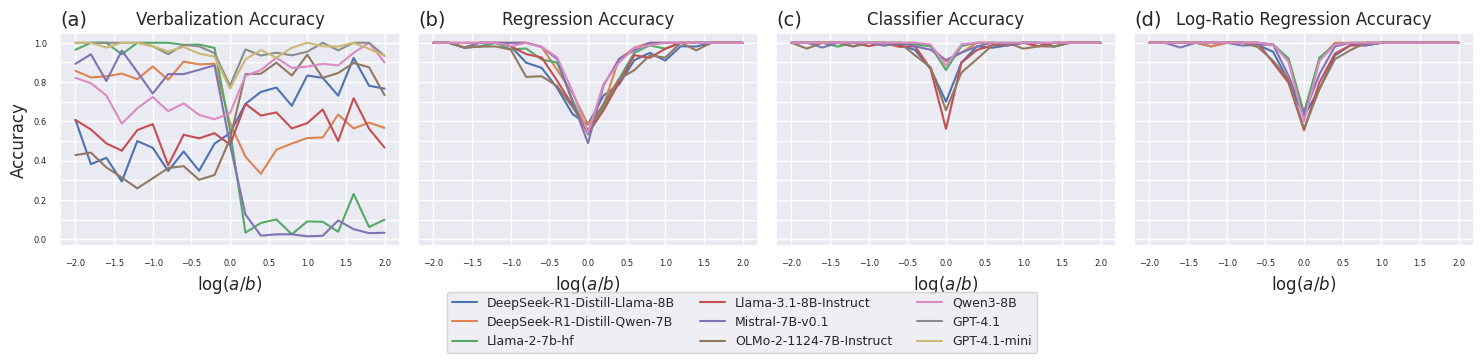

In [32]:
fig, axes = plt.subplots(1, 4, sharey=True, figsize=(15, 3.5))
model_order = [
    "DeepSeek-R1-Distill-Llama-8B",
    "DeepSeek-R1-Distill-Qwen-7B",
    "Llama-2-7b-hf",
    "Llama-3.1-8B-Instruct",
    "Mistral-7B-v0.1",
    "OLMo-2-1124-7B-Instruct",
    "Qwen3-8B",
    "GPT-4.1",
    "GPT-4.1-mini",
]

# (a) verbalization: All models (includes GPT)
sns.lineplot(
    data=df_all.groupby([
        "model",
        pd.cut(df_all["log_ratio"], bins=np.arange(-21, 23, 2) / 10).apply(lambda x: x.right - 0.1)
    ], observed=True)["comparison_correct"].mean().reset_index(),
    x="log_ratio",
    y="comparison_correct",
    hue="model",
    hue_order=model_order,
    ax=axes[0]
).set_title("Verbalization Accuracy")

# (b-d) probes: ONLY probable models
sns.lineplot(
    data=df.groupby([
        "model",
        pd.cut(df["log_ratio"], bins=np.arange(-21, 23, 2) / 10).apply(lambda x: x.right - 0.1)
    ], observed=True)["reg_comparison_correct"].mean().reset_index(),
    x="log_ratio",
    y="reg_comparison_correct",
    hue="model",
    ax=axes[1]
).set_title("Regression Accuracy")

sns.lineplot(
    data=df.groupby([
        "model",
        pd.cut(df["log_ratio"], bins=np.arange(-21, 23, 2) / 10).apply(lambda x: x.right - 0.1)
    ], observed=True)["cls_comparison_correct"].mean().reset_index(),
    x="log_ratio",
    y="cls_comparison_correct",
    hue="model",
    ax=axes[2]
).set_title("Classifier Accuracy")

sns.lineplot(
    data=df.groupby([
        "model",
        pd.cut(df["log_ratio"], bins=np.arange(-21, 23, 2) / 10).apply(lambda x: x.right - 0.1)
    ], observed=True)["lrreg_comparison_correct"].mean().reset_index(),
    x="log_ratio",
    y="lrreg_comparison_correct",
    hue="model",
    ax=axes[3]
).set_title("Log-Ratio Regression Accuracy")

# --- figure-level legend: grab handles before removing per-axis legends
handles, labels = axes[0].get_legend_handles_labels()

for i, ax in enumerate(axes):
    ax.set_ylabel("Accuracy")
    ax.set_xlabel("$\\log(a/b)$")
    ax.set_yticks(np.arange(0.0, 1.1, 0.1), minor=True)
    ax.set_xticks(np.arange(-2.0, 2.5, 0.5), minor=True)
    ax.yaxis.grid(True, which="both")
    ax.xaxis.grid(True, which="both")

    # remove subplot legends; we'll use a single figure legend
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

    label = chr(ord("a") + i)
    ax.set_title(f"({label})", fontsize=14, loc="left")

# one shared legend under all panels
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,           # adjust cols as needed
    fontsize=9,
    frameon=True,
)

plt.tight_layout(rect=[0, 0.08, 1, 1])  # leave space at bottom for legend

fig_dir = os.path.join(ALL_FIG_DIR, "log_ratio_plot", PROBE_SETTING)
if not os.path.exists(fig_dir):
    os.makedirs(fig_dir, exist_ok=True)

plt.savefig(os.path.join(fig_dir, "log_ratio_plot.pdf"), bbox_inches="tight")
plt.savefig(os.path.join(fig_dir, "log_ratio_plot.png"), bbox_inches="tight")

In [25]:
def log_ratio_plot(df, llm_name, ax=None):
    sns.lineplot(
        data=df.groupby([
            pd.cut(df["log_ratio"], bins=np.arange(-21, 23, 2) / 10).apply(lambda x: x.right - 0.1)
        ], observed=True)["comparison_correct"].mean().reset_index(),
        x="log_ratio",
        y="comparison_correct",
        label="Verbalization",
        ax=ax
    )

    sns.lineplot(
        data=df.groupby([
            pd.cut(df["log_ratio"], bins=np.arange(-21, 23, 2) / 10).apply(lambda x: x.right - 0.1)
        ], observed=True)["reg_comparison_correct"].mean().reset_index(),
        x="log_ratio",
        y="reg_comparison_correct",
        label="Regression",
        ax=ax
    )

    sns.lineplot(
        data=df.groupby([
            pd.cut(df["log_ratio"], bins=np.arange(-21, 23, 2) / 10).apply(lambda x: x.right - 0.1)
        ], observed=True)["cls_comparison_correct"].mean().reset_index(),
        x="log_ratio",
        y="cls_comparison_correct",
        label="Classification",
        ax=ax
    )

    sns.lineplot(
        data=df.groupby([
            pd.cut(df["log_ratio"], bins=np.arange(-21, 23, 2) / 10).apply(lambda x: x.right - 0.1)
        ], observed=True)["lrreg_comparison_correct"].mean().reset_index(),
        x="log_ratio",
        y="lrreg_comparison_correct",
        label="Log-Ratio Regression",
        ax=ax
    )

    if ax is None:
        plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7)
        plt.title(llm_name, fontsize=16)
    else:
        ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7)
        ax.set_title(llm_name, fontsize=16)

    ax.set_ylabel("Accuracy")
    ax.set_xlabel("$\\log(a/b)$")

In [28]:
sorted_llms

[{'name': 'DeepSeek-R1-Distill-Llama-8B',
  'pretty': 'DeepSeek-R1-Distill-Llama-8B',
  'num_layers': 32},
 {'name': 'DeepSeek-R1-Distill-Qwen-7B',
  'pretty': 'DeepSeek-R1-Distill-Qwen-7B',
  'num_layers': 28},
 {'name': 'Llama-2-7b-hf', 'pretty': 'Llama-2-7b-hf', 'num_layers': 32},
 {'name': 'Llama-3.1-8B-Instruct',
  'pretty': 'Llama-3.1-8B-Instruct',
  'num_layers': 32},
 {'name': 'Mistral-7B-v0.1', 'pretty': 'Mistral-7B-v0.1', 'num_layers': 32},
 {'name': 'OLMo-2-1124-7B-Instruct',
  'pretty': 'OLMo-2-1124-7B-Instruct',
  'num_layers': 32},
 {'name': 'Qwen3-8B', 'pretty': 'Qwen3-8B', 'num_layers': 36}]

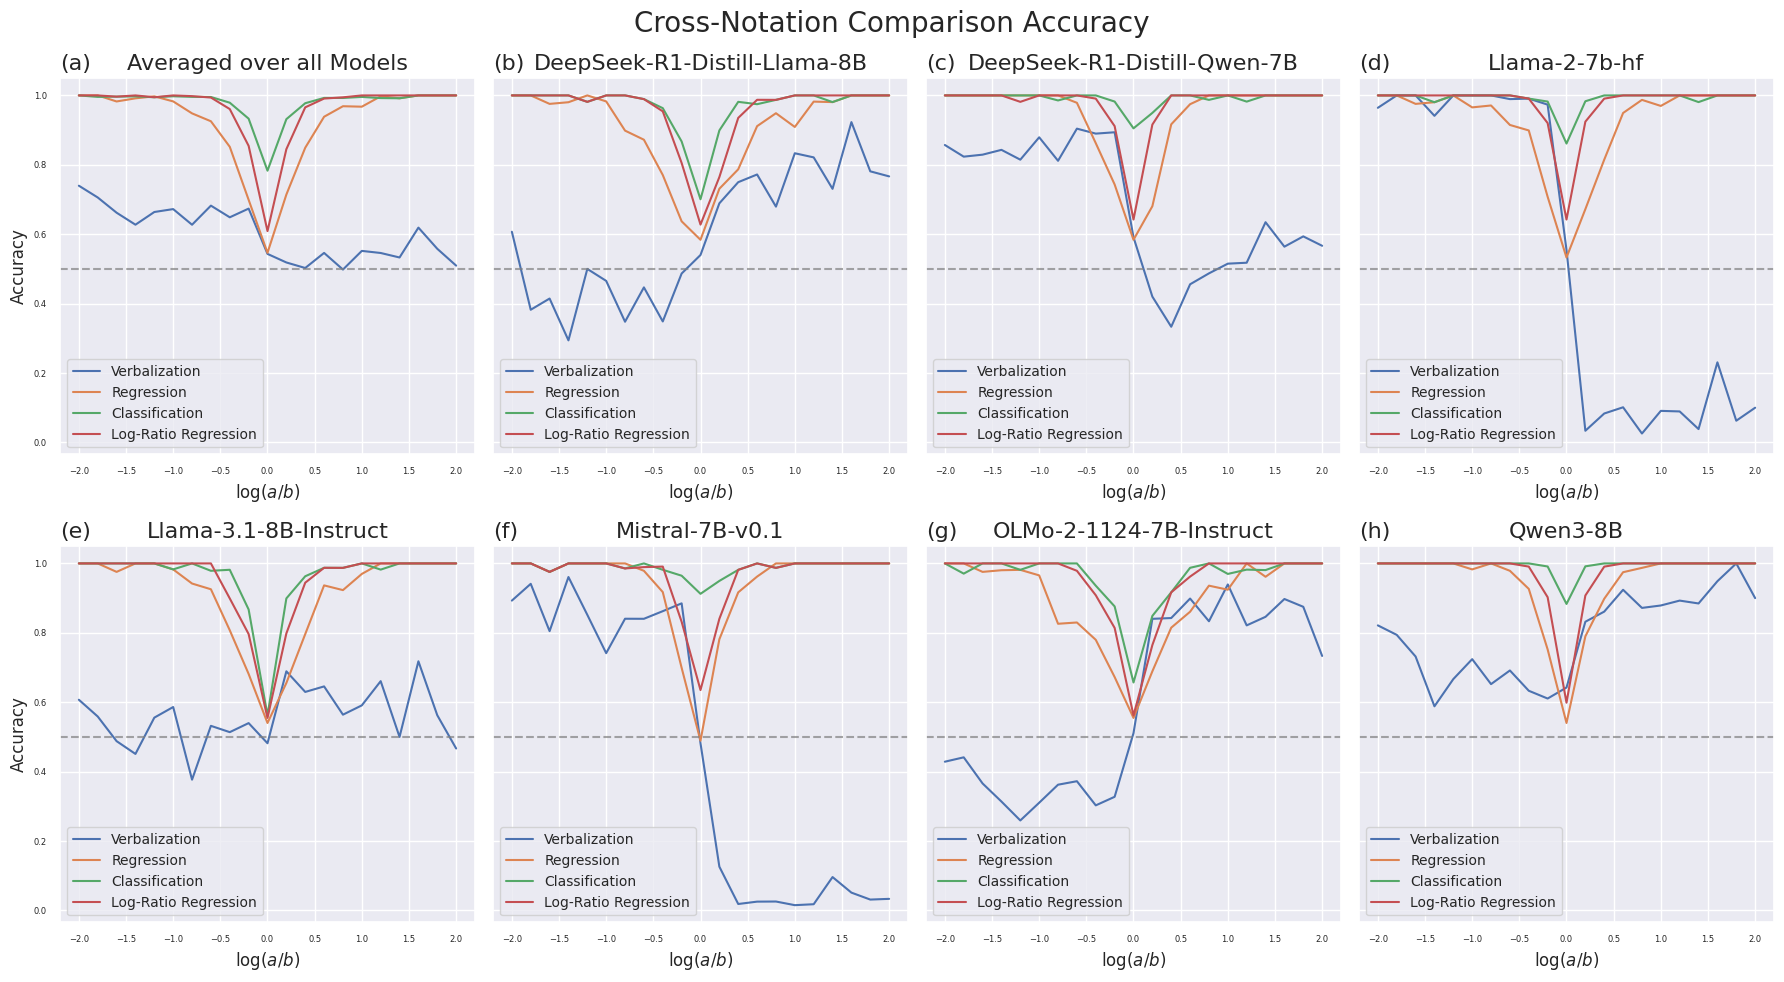

In [33]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10), sharey=True)

log_ratio_plot(df, "Averaged over all Models", ax=axes[0, 0])

for idx, llmdict in enumerate(sorted_llms):
    idx += 1  # offset the model average
    llmname = llmdict["name"]
    llmdf = df[df["model"] == llmname]
    log_ratio_plot(llmdf, llmname, ax=axes[idx // 4, idx % 4])

for idx in range(axes.size):

    label = chr(ord('a') + idx)  # 'a', 'b', 'c', ...
    axes[idx // 4, idx % 4].set_title(f'({label})', fontsize=16, loc='left')

fig.suptitle("Cross-Notation Comparison Accuracy", fontsize=20)

plt.tight_layout()
fig_dir = os.path.join(ALL_FIG_DIR, "log_ratio_plot", PROBE_SETTING)
if not os.path.exists(fig_dir):
    os.makedirs(fig_dir, exist_ok=True)

plt.savefig(os.path.join(fig_dir, "log_ratio_plot_individual_models.pdf"), bbox_inches="tight")
plt.savefig(os.path.join(fig_dir, "log_ratio_plot_individual_models.png"), bbox_inches="tight")

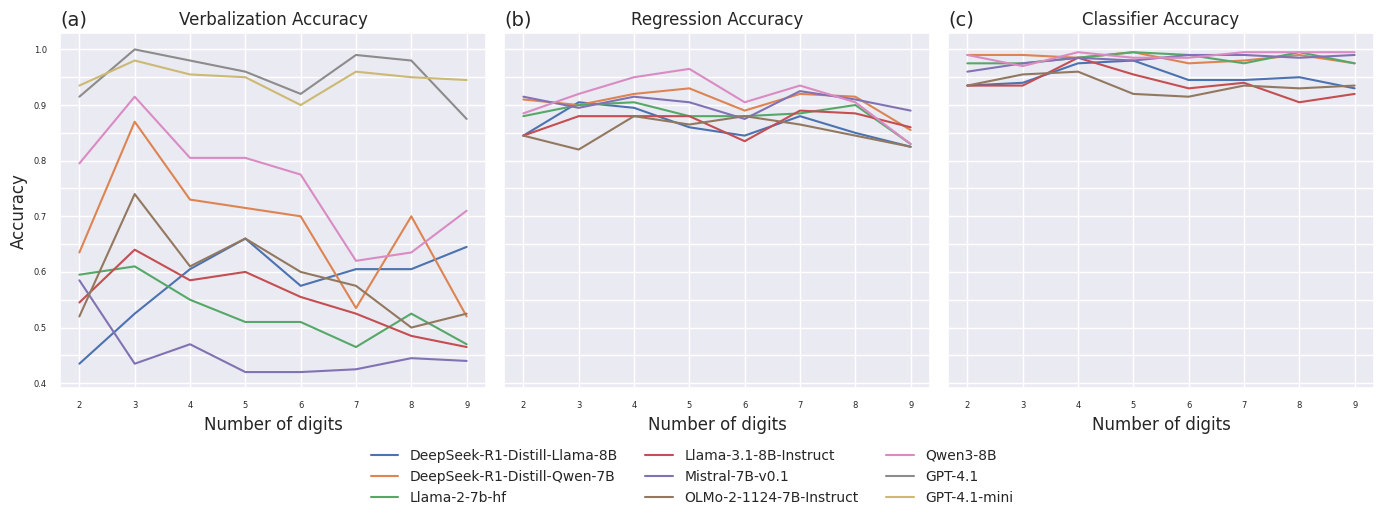

In [34]:
# fig, axes = plt.subplots(1, 4, sharey=True, figsize=(15, 4))
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(14, 5))

sns.lineplot(
    data=df_all.groupby([
        "model",
        "digit"
    ])["comparison_correct"].mean().reset_index(),
    x="digit",
    y="comparison_correct",
    hue="model",
    hue_order=model_order,
    ax=axes[0]
).set_title("Verbalization Accuracy")

sns.lineplot(
    data=df.groupby([
        "model",
        "digit"
    ])["reg_comparison_correct"].mean().reset_index(),
    x="digit",
    y="reg_comparison_correct",
    hue="model",
    ax=axes[1]
).set_title("Regression Accuracy")

sns.lineplot(
    data=df.groupby([
        "model",
        "digit"
    ])["cls_comparison_correct"].mean().reset_index(),
    x="digit",
    y="cls_comparison_correct",
    hue="model",
    ax=axes[2]
).set_title("Classifier Accuracy")

# sns.lineplot(
#     data=df.groupby([
#         "model",
#         "digit"
#     ])["lrreg_comparison_correct"].mean().reset_index(),
#     x="digit",
#     y="lrreg_comparison_correct",
#     hue="model",
#     ax=axes[3]
# ).set_title("Log-Ratio Regression Accuracy")
# --- figure-level legend: grab handles before removing per-axis legends
handles, labels = axes[0].get_legend_handles_labels()

for idx, ax in enumerate(axes):
    label = chr(ord('a') + idx)  # 'a', 'b', 'c', ...
    ax.set_title(f'({label})', fontsize=14, loc='left')

    # if idx != len(axes)-1:  # remove legend except for the last
    #     ax.legend([])
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

    ax.set_xlabel("Number of digits")
    ax.set_ylabel("Accuracy")

    ax.set_yticks(np.arange(0.4, 1.05, 0.05), minor=True)
    ax.yaxis.grid(True, which="both")

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,           # adjust cols as needed
    fontsize=10,
    frameon=False,
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
ALL_FIG_DIR = "../figures/"
fig_dir = os.path.join(ALL_FIG_DIR, "error_analysis")
if not os.path.exists(fig_dir):
    os.makedirs(fig_dir, exist_ok=True)

plt.savefig(os.path.join(fig_dir, "digit_plot.pdf"), bbox_inches="tight")
plt.savefig(os.path.join(fig_dir, "digit_plot.png"), bbox_inches="tight")

In [30]:
df_all["log_sum"] = np.log2(df_all["a_val"]+df_all["b_val"])
df['log_sum'] = np.log2(df['a_val']+df['b_val'])

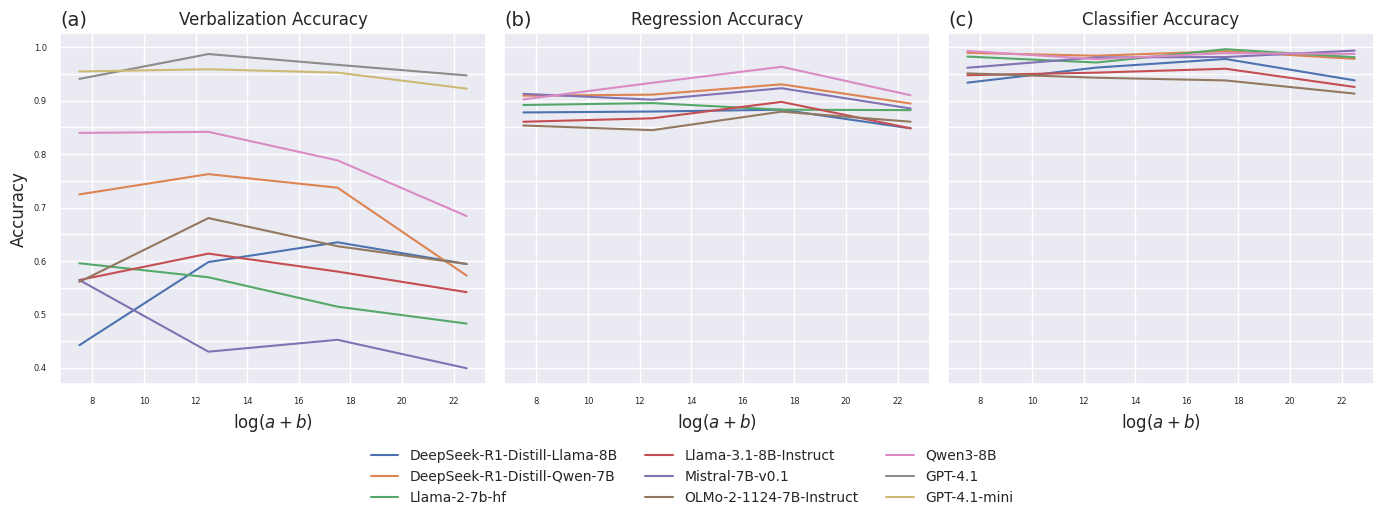

In [35]:
# fig, axes = plt.subplots(1, 4, sharey=True, figsize=(15, 4))
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(14, 5))
# see original error_analysis_probes.ipynb for original code

sns.lineplot(
    data=df_all.groupby([
        "model",
        pd.cut(df_all["log_sum"], bins=np.arange(5, 30, 5)).apply(lambda x: x.right - 2.5)
    ], observed=True)["comparison_correct"].mean().reset_index(),
    x="log_sum",
    y="comparison_correct",
    hue="model",
    hue_order=model_order,
    ax=axes[0]
).set_title("Verbalization Accuracy")

sns.lineplot(
    data=df.groupby([
        "model",
        pd.cut(df["log_sum"], bins=np.arange(5, 30, 5)).apply(lambda x: x.right - 2.5)
    ], observed=True)["reg_comparison_correct"].mean().reset_index(),
    x="log_sum",
    y="reg_comparison_correct",
    hue="model",
    ax=axes[1]
).set_title("Regression Accuracy")

sns.lineplot(
    data=df.groupby([
        "model",
        pd.cut(df["log_sum"], bins=np.arange(5, 30, 5)).apply(lambda x: x.right - 2.5)
    ], observed=True)["cls_comparison_correct"].mean().reset_index(),
    x="log_sum",
    y="cls_comparison_correct",
    hue="model",
    ax=axes[2]
).set_title("Classifier Accuracy")

# sns.lineplot(
#     data=df.groupby([
#         "model",
#         pd.cut(df["log_sum"], bins=np.arange(5, 30, 5)).apply(lambda x: x.right - 2.5)
#     ], observed=True)["lrreg_comparison_correct"].mean().reset_index(),
#     x="log_sum",
#     y="lrreg_comparison_correct",
#     hue="model",
#     ax=axes[3]
# ).set_title("Log-Ratio Regression Accuracy")

# --- figure-level legend: grab handles before removing per-axis legends
handles, labels = axes[0].get_legend_handles_labels()

for idx, ax in enumerate(axes):
    label = chr(ord('a') + idx)  # 'a', 'b', 'c', ...
    ax.set_title(f'({label})', fontsize=14, loc='left')

    # remove subplot legends; we'll use a single figure legend
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

    ax.set_xlabel("$\\log(a+b)$")
    ax.set_ylabel("Accuracy")

    ax.set_yticks(np.arange(0.4, 1.05, 0.05), minor=True)
    ax.yaxis.grid(True, which="both")

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,           # adjust cols as needed
    fontsize=10,
    frameon=False,
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
ALL_FIG_DIR = "../figures/"
fig_dir = os.path.join(ALL_FIG_DIR, "error_analysis")
if not os.path.exists(fig_dir):
    os.makedirs(fig_dir, exist_ok=True)

plt.savefig(os.path.join(fig_dir, "magnitude_plot.pdf"), bbox_inches="tight")
plt.savefig(os.path.join(fig_dir, "magnitude_plot.png"), bbox_inches="tight")